# Signal Analysis

## Step 1: Notebook setup and frequency-domain definition

In this notebook, I will simulate and analyze radio astronomy signals by following the required workflow:
- signal simulation
- smoothing
- calibration
- spectral line detection
- upsampling
- fitting
- error estimation

The analysis is centered around the hydrogen spectral line at 1420 MHz.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

In [3]:
# Reproducibility
np.random.seed(42)

# Plot settings
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

In [4]:
# Frequency-domain parameters
n_samples = 512
f_min = 1418.0
f_max = 1422.0
freq = np.linspace(f_min, f_max, n_samples)

# Time-domain parameter for the waterfall
n_seg = 80

# Hydrogen line frequency
f0 = 1420.0

# Basic checks
bandwidth = f_max - f_min
frequency_resolution = bandwidth / (n_samples - 1)

print(f"Number of frequency samples: {n_samples}")
print(f"Frequency range: {f_min:.3f} - {f_max:.3f} MHz")
print(f"Bandwidth: {bandwidth:.3f} MHz")
print(f"Frequency resolution: {frequency_resolution:.6f} MHz")
print(f"Number of time segments: {n_seg}")
print(f"Hydrogen line center: {f0:.3f} MHz")

Number of frequency samples: 512
Frequency range: 1418.000 - 1422.000 MHz
Bandwidth: 4.000 MHz
Frequency resolution: 0.007828 MHz
Number of time segments: 80
Hydrogen line center: 1420.000 MHz


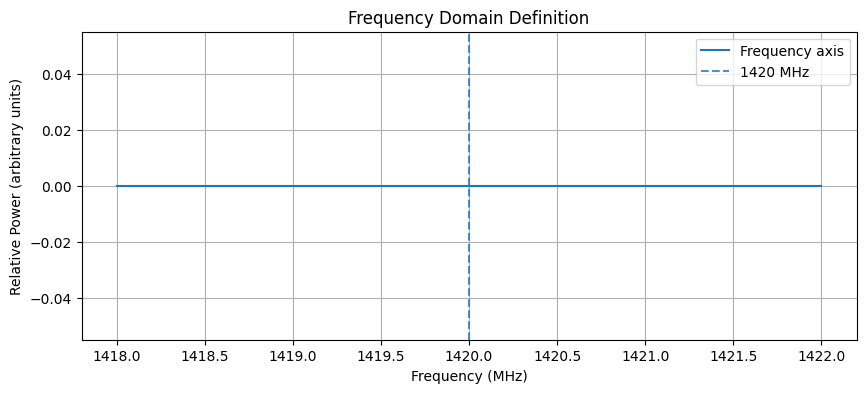

In [5]:
plt.plot(freq, np.zeros_like(freq), label="Frequency axis")
plt.axvline(f0, linestyle="--", alpha=0.8, label="1420 MHz")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Relative Power (arbitrary units)")
plt.title("Frequency Domain Definition")
plt.legend()
plt.show()

### Step 1 summary

The frequency axis has been defined around the hydrogen line at 1420 MHz, with a total bandwidth of 4 MHz and 512 samples.  
This provides the basis for simulating the OFF and ON radio signals in the next step.

## Step 2: Background modeling and OFF signal simulation

In this step, we simulate the OFF signal, which consists of:
- a smooth background signal
- Gaussian noise that varies across time segments

The OFF signal does not contain any spectral line and will later be used for calibration.

In [8]:
def background_model(f):
  x = (f - np.mean(f)) / (f.max() - f.min())

  bg = (
      - 13.2
      - 3.8 * x**4
      + 0.35 * np.sin(2 * np.pi * 1.3 * x)
      - 0.20 * np.cos(2 * np.pi * 2.1 * x)
  )

  return bg

background = background_model(freq)

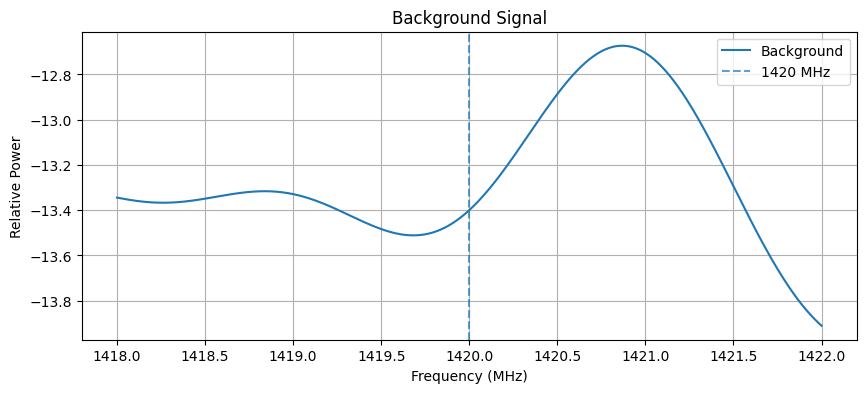

In [9]:
plt.plot(freq, background, label="Background")
plt.axvline(f0, linestyle="--", alpha=0.7, label="1420 MHz")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Relative Power")
plt.title("Background Signal")
plt.legend()
plt.show()

In [10]:
noise_std = 0.12

off_signal = np.array([
    background + np.random.normal(0, noise_std, size=n_samples)
    for _ in range(n_seg)
])

In [11]:
print(off_signal.shape)

(80, 512)


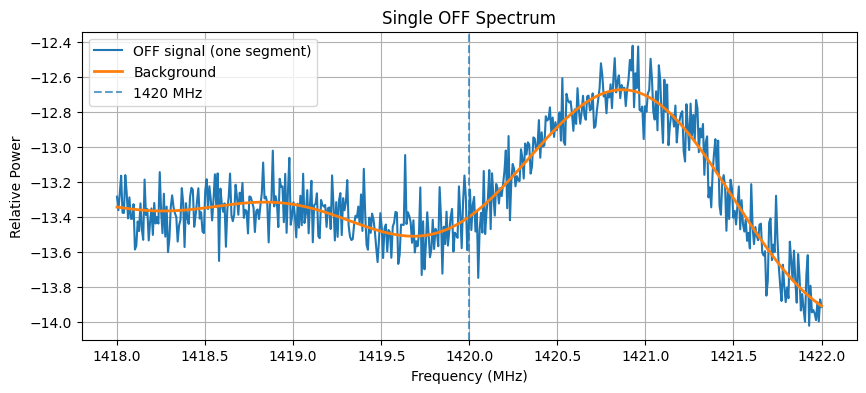

In [12]:
plt.plot(freq, off_signal[0], label="OFF signal (one segment)")
plt.plot(freq, background, linewidth=2, label="Background")
plt.axvline(f0, linestyle="--", alpha=0.7, label="1420 MHz")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Relative Power")
plt.title("Single OFF Spectrum")
plt.legend()
plt.show()

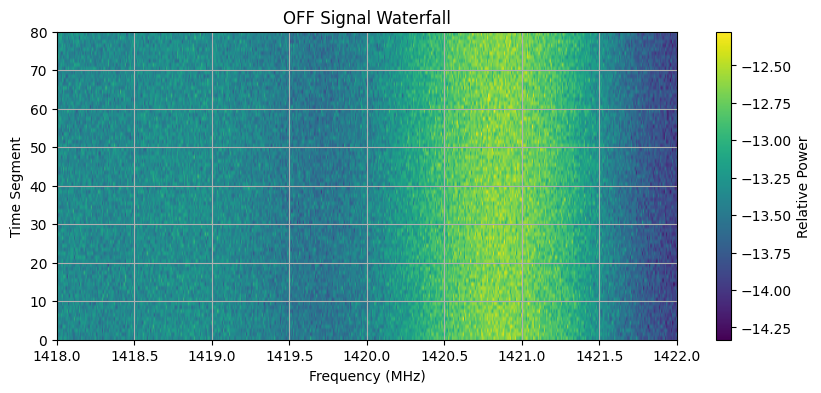

In [14]:
plt.imshow(
    off_signal,
    aspect="auto",
    origin="lower",
    extent=[f_min, f_max, 0, n_seg],
)

plt.colorbar(label="Relative Power")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Time Segment")
plt.title("OFF Signal Waterfall")
plt.show()